# Layer-based Targeting Plotting

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
def plot(dir, desc):
    with open(f'./{dir}/gpu_usage_log.json', 'r') as file:
        gpu = json.load(file)

    with open(f'./{dir}/ram_usage_log.json', 'r') as file:
        ram = json.load(file)

    with open(f'./{dir}/training_results_detailed_test.json', 'r') as file:
        results= json.load(file)
        baseline_ram= results['baseline_ram_gb']
        baseline_gpu= results['baseline_gpu_gb']


    chunk_size = 10
    gpu=np.array(gpu)-baseline_gpu
    ram=np.array(ram)-baseline_ram
    

    gpu_usage = [
        gpu[i]
        for i in range(0, len(gpu), chunk_size)
    ]

    ram_usage = [
        ram[i]
        for i in range(0, len(ram), chunk_size)
    ]
    
    time_stamps = [x for x in range(len(gpu_usage))]  # Using index as timestamp if actual timestamps are not available
    # time_deltas = (time_stamps - time_stamps[0]).total_seconds() / 60  # Convert to minutes
    
    # Plot GPU and RAM usage over time
    plt.figure(figsize=(12, 6))
    plt.plot(time_stamps, gpu_usage, label='GPU Usage ', color='blue')
    plt.plot(time_stamps, ram_usage, label='RAM Usage', color='orange')
    plt.xlabel('Time')
    plt.ylabel('Usage')
    plt.title(f"GPU and RAM Usage over Time ({desc})")
    plt.legend()
    plt.grid(True)
    plt.show()

In [3]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_loss(dir,desc):
    with open(f'./{dir}/log.json', 'r') as file:
        log = json.load(file)
        
    loss=[x['loss'] for x in log[:-2]]
    step=[x['step'] for x in log[:-2]]
    
    plt.grid(True)
    plt.plot(step,loss)
    plt.xlabel('Number of Steps')
    plt.ylabel('Loss')
    plt.title(f'Training Loss over Number of Steps ({desc})')

def plot_conf_matrix(dir, desc):
    with open(f'./{dir}/prediction_answers.json', 'r') as file:
        res = json.load(file)
    
    preds = res['predictions']
    true = res['labels']
    labels = ['World', 'Sports', 'Business', 'Sci/Tech']

    cm = confusion_matrix(true, preds)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

    # Plot confusion matrix
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix ({desc})")
    plt.show()

In [4]:
def plot_results(dir):
    with open(f'./{dir}/training_results_detailed_test.json', 'r') as f:
        results = json.load(f)
    
    df = pd.DataFrame(results.items(), columns=['Metric', 'Value'])
    
    # Format value type
    def format_value(row):
        metric, value = row['Metric'], row['Value']
        if metric in ['total_parameters', 'trainable_parameters']:
            return f'{int(value):,}'
        elif metric in ['training_time_seconds', 'test_inference_time_seconds']:
            return f'{value:.2f}s'
        elif 'percentage' in metric:
            return f'{value:.2f}%'
        elif 'gb' in metric.lower():
            return f'{value:.4f} GB'
        else:
            return f'{value:.4f}'
    
    df['Value'] = df.apply(format_value, axis=1)
    display(df.style.hide(axis='index'))

### Layer 0 Fine-tune

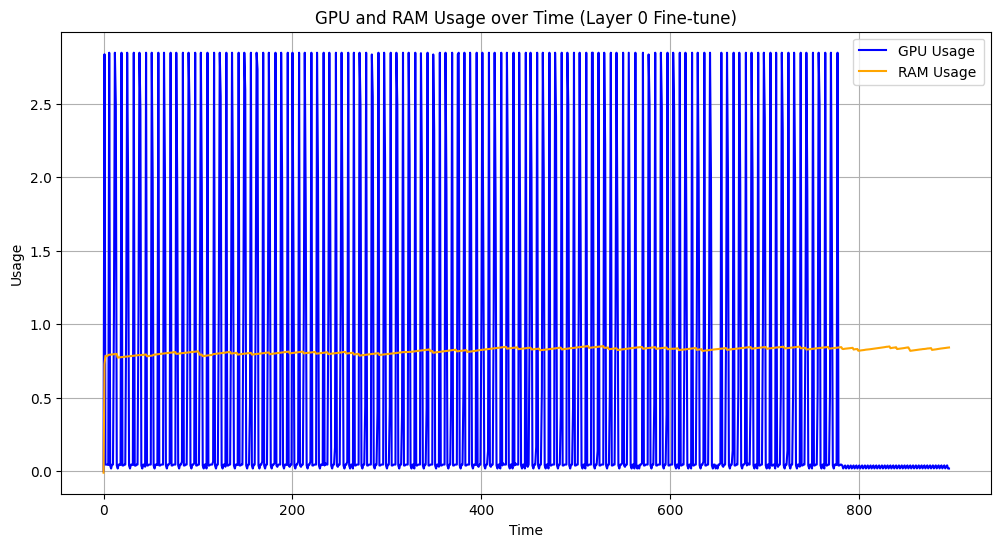

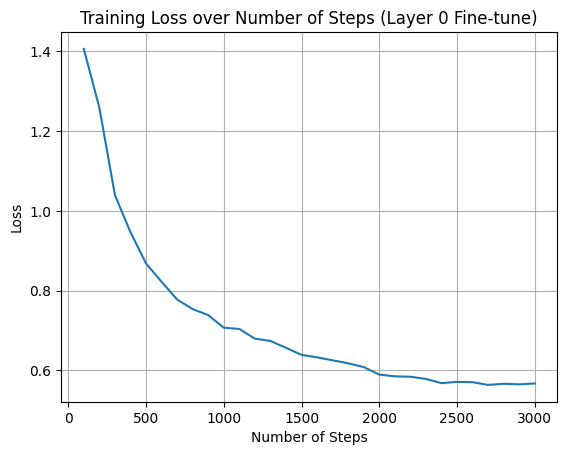

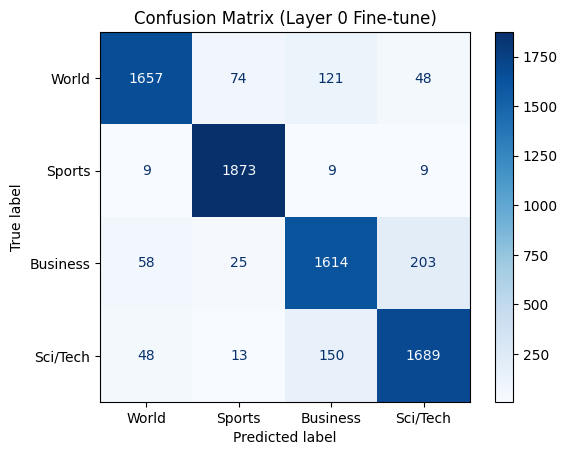

Metric,Value
test_accuracy,0.8991
test_accuracy_percentage,89.91%
validation_accuracy,0.8978
training_time_seconds,920.44s
test_inference_time_seconds,38.58s
peak_gpu_memory_during_training_gb,3.5172 GB
peak_ram_usage_during_training_gb,14.0247 GB
gpu_memory_increase_during_training_gb,2.9870 GB
ram_increase_during_training_gb,0.8521 GB
baseline_ram_gb,13.1725 GB


In [5]:
plot('results_inference-based_20260311_185448', 'Layer 0 Fine-tune')
plot_loss('results_inference-based_20260311_185448', 'Layer 0 Fine-tune')
plot_conf_matrix('results_inference-based_20260311_185448', 'Layer 0 Fine-tune')
plot_results('results_inference-based_20260311_185448')

### Layer 5 Fine-tune

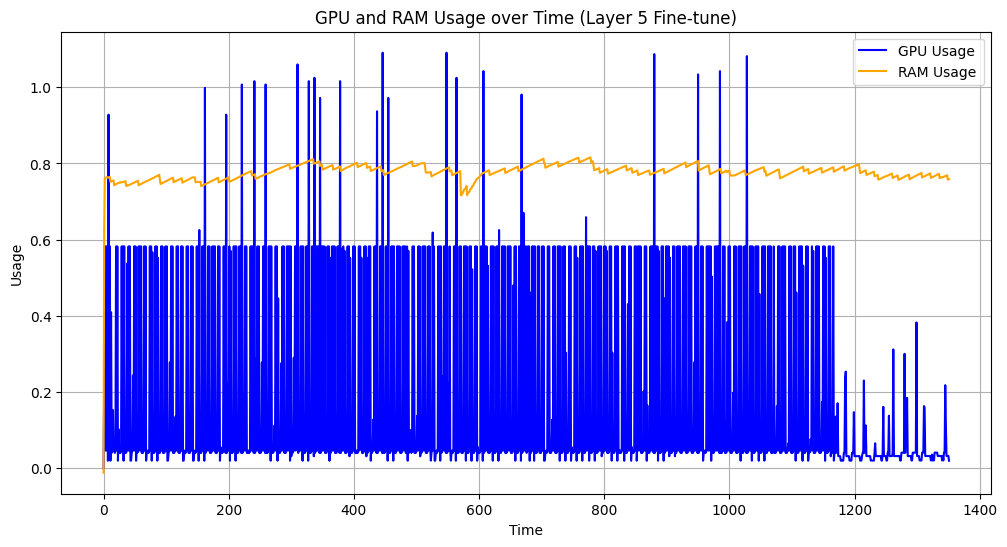

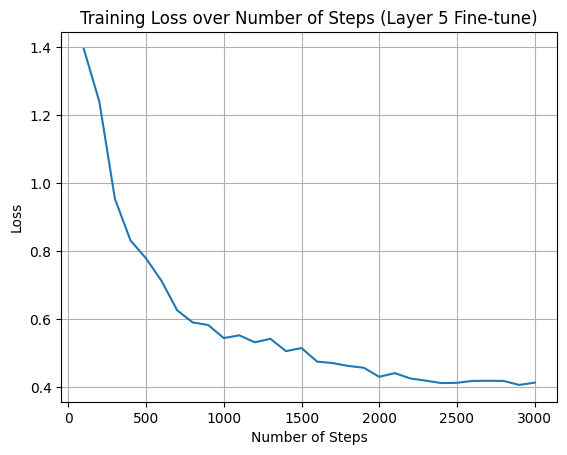

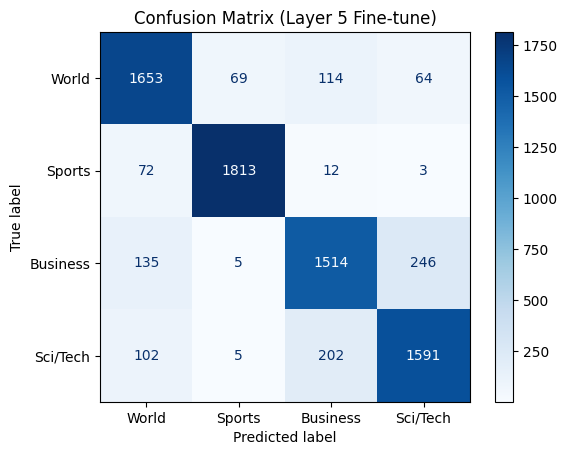

Metric,Value
test_accuracy,0.8646
test_accuracy_percentage,86.46%
validation_accuracy,0.8655
training_time_seconds,1367.71s
test_inference_time_seconds,59.12s
peak_gpu_memory_during_training_gb,1.6210 GB
peak_ram_usage_during_training_gb,16.6835 GB
gpu_memory_increase_during_training_gb,1.0908 GB
ram_increase_during_training_gb,0.8159 GB
baseline_ram_gb,15.8676 GB


In [6]:
plot('results_inference-based_20260310_200728', 'Layer 5 Fine-tune')
plot_loss('results_inference-based_20260310_200728', 'Layer 5 Fine-tune')
plot_conf_matrix('results_inference-based_20260310_200728', 'Layer 5 Fine-tune')
plot_results('results_inference-based_20260310_200728')

### Bottom 33% Fine-tune

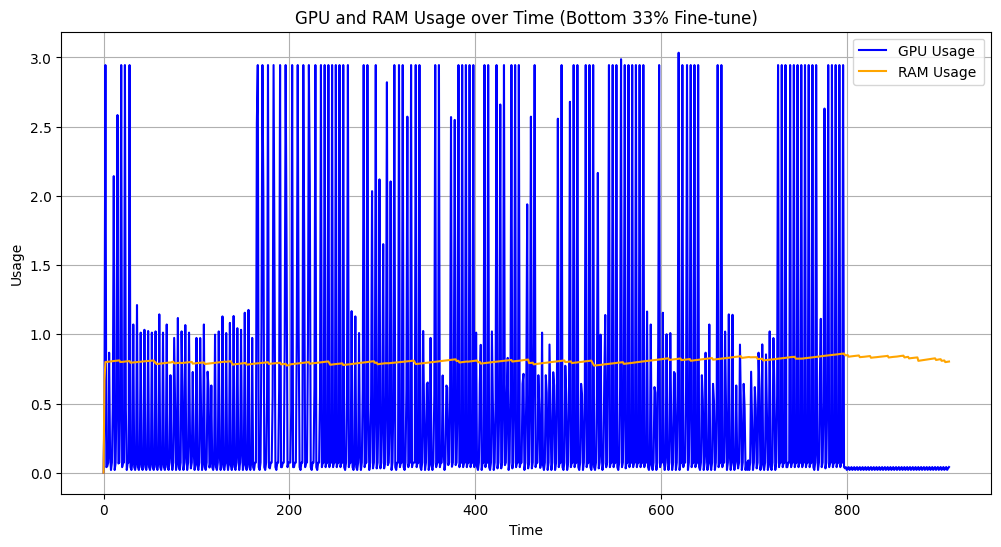

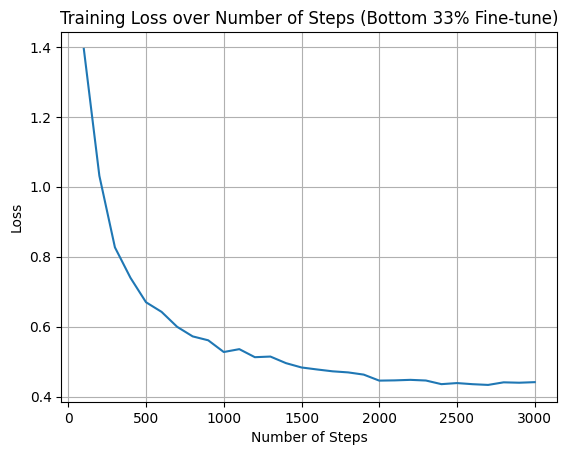

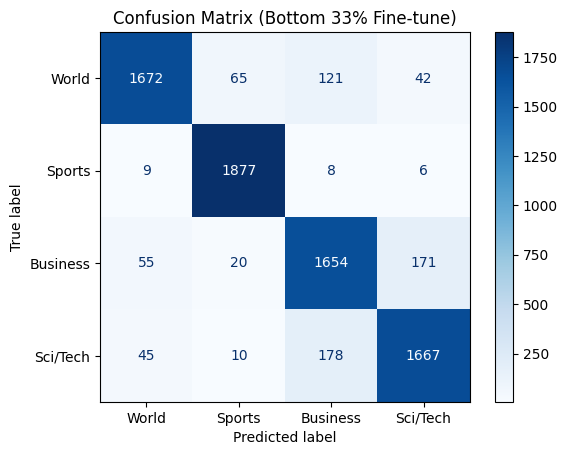

Metric,Value
test_accuracy,0.9039
test_accuracy_percentage,90.39%
validation_accuracy,0.9037
training_time_seconds,934.29s
test_inference_time_seconds,38.78s
peak_gpu_memory_during_training_gb,3.5915 GB
peak_ram_usage_during_training_gb,14.0985 GB
gpu_memory_increase_during_training_gb,3.0608 GB
ram_increase_during_training_gb,0.8616 GB
baseline_ram_gb,13.2369 GB


In [7]:
plot('results_inference-based_20260311_191916', 'Bottom 33% Fine-tune')
plot_loss('results_inference-based_20260311_191916', 'Bottom 33% Fine-tune')
plot_conf_matrix('results_inference-based_20260311_191916', 'Bottom 33% Fine-tune')
plot_results('results_inference-based_20260311_191916')

### Top 33% Fine-tune

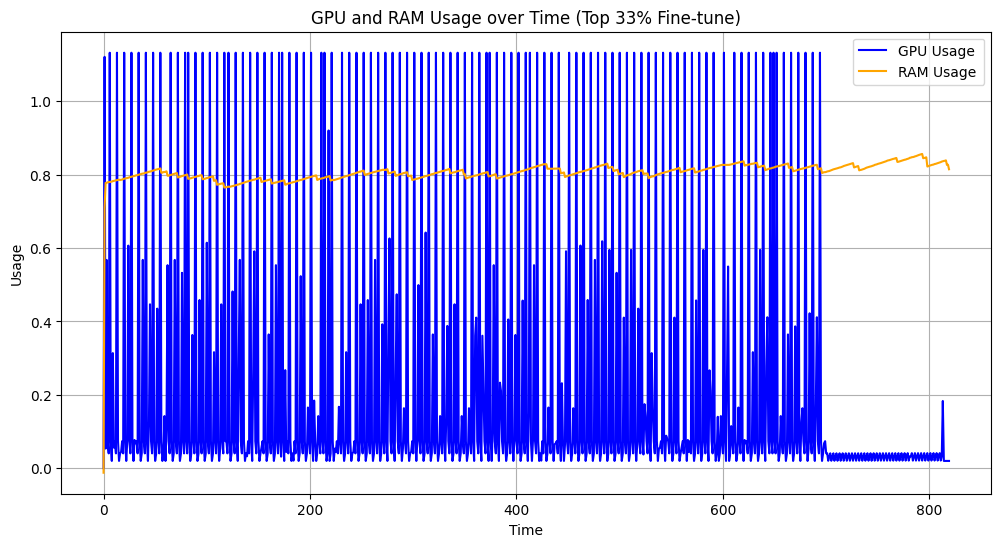

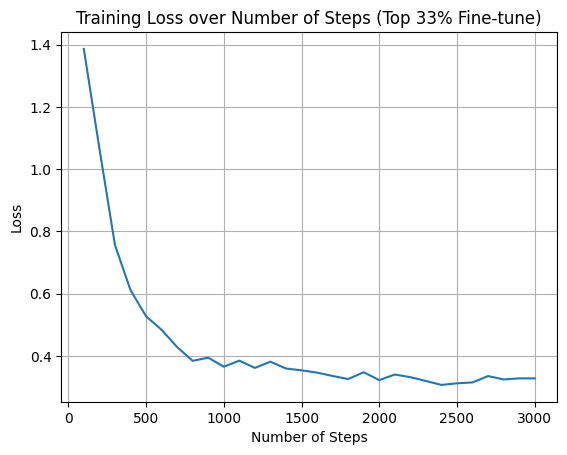

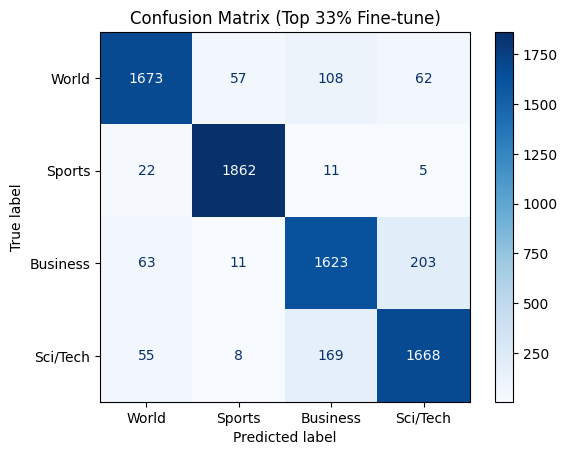

Metric,Value
test_accuracy,0.8982
test_accuracy_percentage,89.82%
validation_accuracy,0.9001
training_time_seconds,842.96s
test_inference_time_seconds,38.83s
peak_gpu_memory_during_training_gb,1.6631 GB
peak_ram_usage_during_training_gb,14.1215 GB
gpu_memory_increase_during_training_gb,1.1325 GB
ram_increase_during_training_gb,0.8566 GB
baseline_ram_gb,13.2649 GB


In [8]:
plot('results_inference-based_20260311_194406', 'Top 33% Fine-tune')
plot_loss('results_inference-based_20260311_194406', 'Top 33% Fine-tune')
plot_conf_matrix('results_inference-based_20260311_194406', 'Top 33% Fine-tune')
plot_results('results_inference-based_20260311_194406')

### Bottom 50% Fine-tune

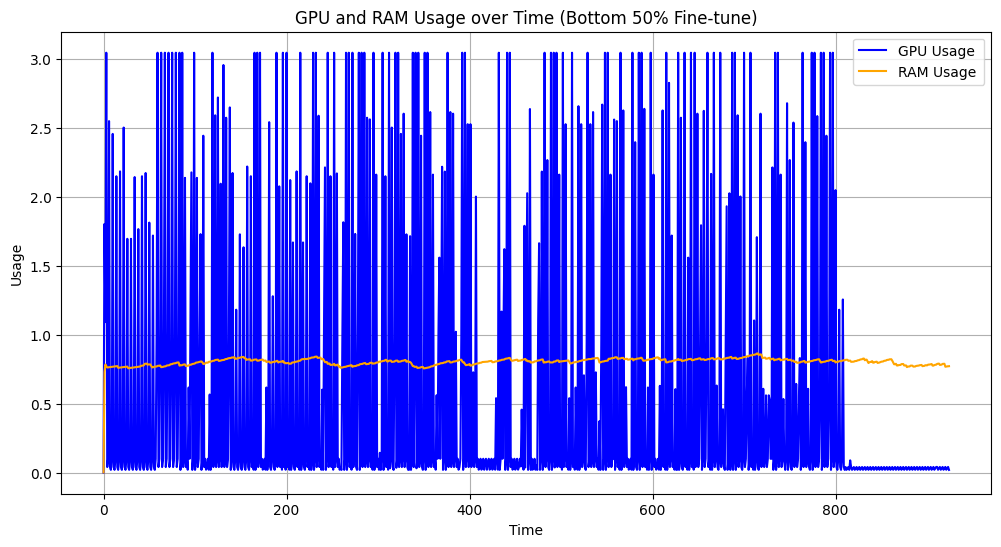

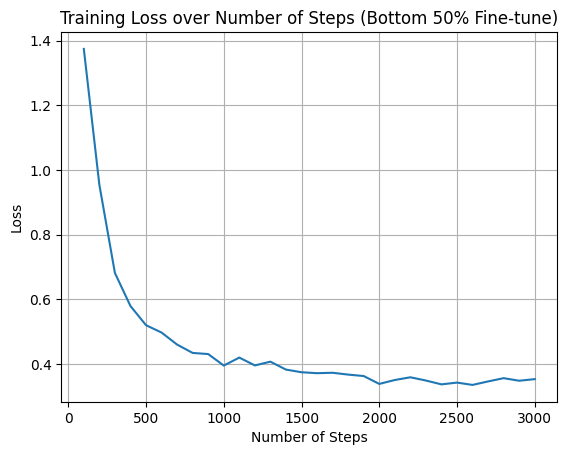

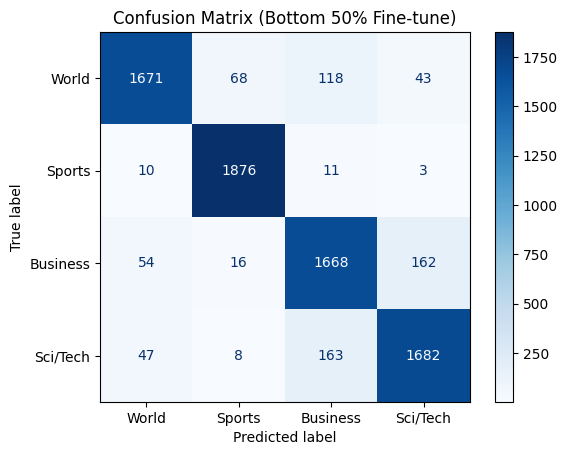

Metric,Value
test_accuracy,0.9075
test_accuracy_percentage,90.75%
validation_accuracy,0.9091
training_time_seconds,955.18s
test_inference_time_seconds,38.83s
peak_gpu_memory_during_training_gb,3.6725 GB
peak_ram_usage_during_training_gb,16.1247 GB
gpu_memory_increase_during_training_gb,3.1415 GB
ram_increase_during_training_gb,0.8640 GB
baseline_ram_gb,15.2607 GB


In [9]:
plot('results_inference-based_20260312_142107', 'Bottom 50% Fine-tune')
plot_loss('results_inference-based_20260312_142107', 'Bottom 50% Fine-tune')
plot_conf_matrix('results_inference-based_20260312_142107', 'Bottom 50% Fine-tune')
plot_results('results_inference-based_20260312_142107')

### Top 50% Fine-tune

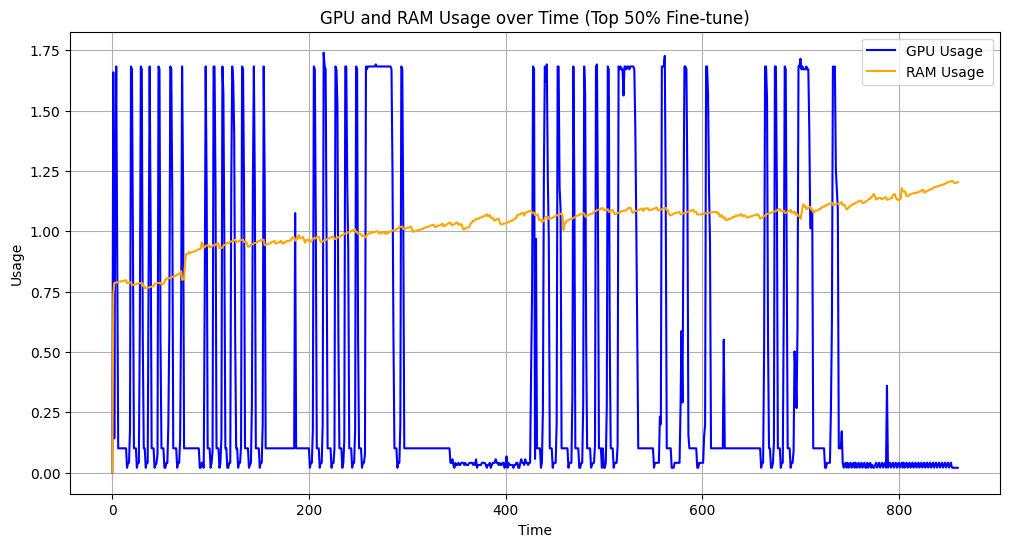

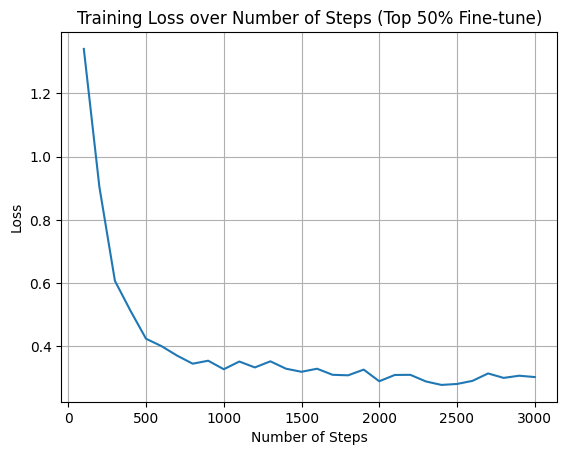

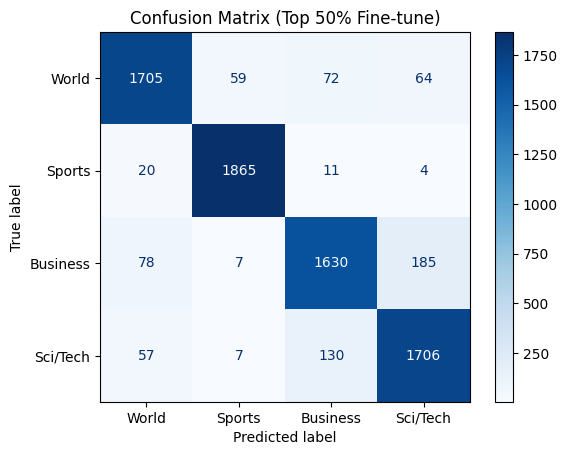

Metric,Value
test_accuracy,0.9087
test_accuracy_percentage,90.87%
validation_accuracy,0.9095
training_time_seconds,886.95s
test_inference_time_seconds,38.77s
peak_gpu_memory_during_training_gb,2.2930 GB
peak_ram_usage_during_training_gb,16.2088 GB
gpu_memory_increase_during_training_gb,1.7619 GB
ram_increase_during_training_gb,1.2082 GB
baseline_ram_gb,15.0006 GB


In [10]:
plot('results_inference-based_20260312_130217', 'Top 50% Fine-tune')
plot_loss('results_inference-based_20260312_130217', 'Top 50% Fine-tune')
plot_conf_matrix('results_inference-based_20260312_130217', 'Top 50% Fine-tune')
plot_results('results_inference-based_20260312_130217')

### Interval Fine-tune (Layer 1, Layer 3, Layer 5)

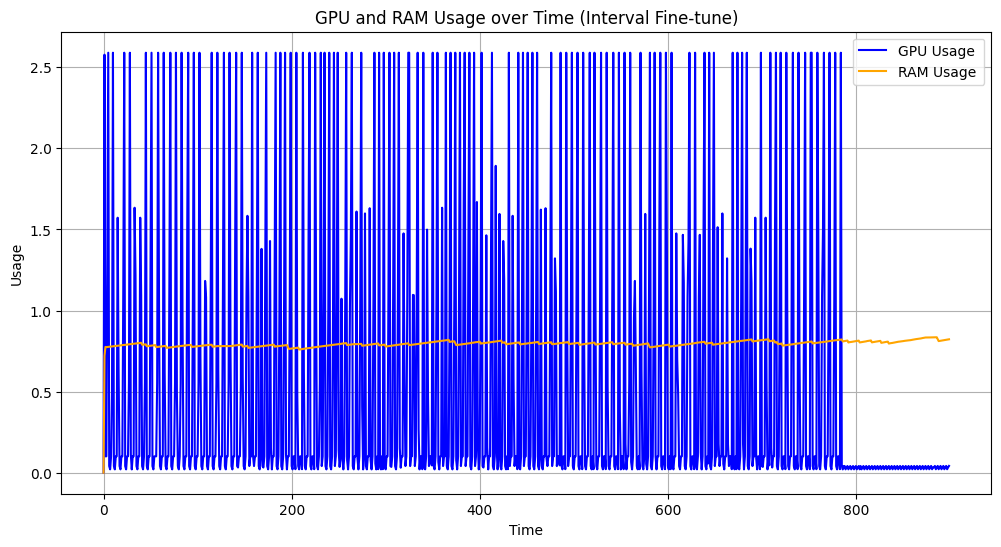

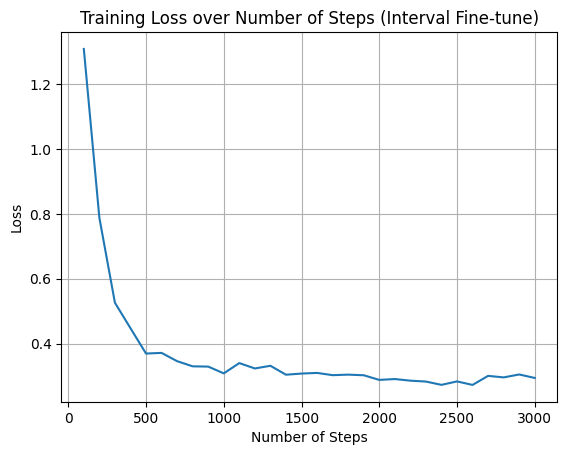

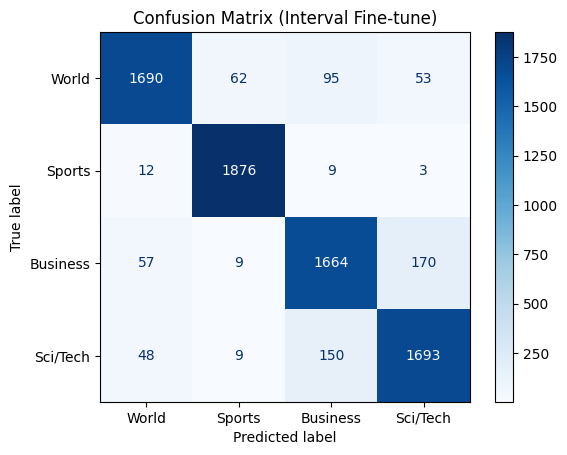

Metric,Value
test_accuracy,0.9109
test_accuracy_percentage,91.09%
validation_accuracy,0.9123
training_time_seconds,932.14s
test_inference_time_seconds,38.88s
peak_gpu_memory_during_training_gb,3.1204 GB
peak_ram_usage_during_training_gb,14.1047 GB
gpu_memory_increase_during_training_gb,2.5894 GB
ram_increase_during_training_gb,0.8353 GB
baseline_ram_gb,13.2695 GB


In [11]:
plot('results_inference-based_20260311_202807', 'Interval Fine-tune')
plot_loss('results_inference-based_20260311_202807', 'Interval Fine-tune')
plot_conf_matrix('results_inference-based_20260311_202807', 'Interval Fine-tune')
plot_results('results_inference-based_20260311_202807')

### All Results

In [12]:
def plot_all_results():
    dirs = [
        ('results_inference-based_20260311_185448', 'Layer 0'),
        ('results_inference-based_20260310_200728', 'Layer 5'),
        ('results_inference-based_20260311_191916', 'Bottom 33%'),
        ('results_inference-based_20260311_194406', 'Top 33%'),
        ('results_inference-based_20260312_142107', 'Bottom 50%'),
        ('results_inference-based_20260312_130217', 'Top 50%'),
        ('results_inference-based_20260311_202807', 'Interval')
    ]
    
    all_dfs = []
    for dir, label in dirs:
        with open(f'./{dir}/training_results_detailed_test.json', 'r') as f:
            results = json.load(f)
        
        def format_value(row):
            metric, value = row['Metric'], row['Value']
            if metric in ['total_parameters', 'trainable_parameters']:
                return f'{int(value):,}'
            elif metric in ['training_time_seconds', 'test_inference_time_seconds']:
                return f'{value:.2f}s'
            elif 'percentage' in metric:
                return f'{value:.2f}%'
            elif 'gb' in metric.lower():
                return f'{value:.4f} GB'
            else:
                return f'{value:.4f}'
        
        df = pd.DataFrame(results.items(), columns=['Metric', label])
        df[label] = df.apply(lambda row: format_value(pd.Series({'Metric': row['Metric'], 'Value': row[label]})), axis=1)
        all_dfs.append(df)
    
    # Merge
    combined = all_dfs[0]
    for df in all_dfs[1:]:
        combined = combined.merge(df, on='Metric')
    
    display(combined.style.hide(axis='index'))

plot_all_results()

Metric,Layer 0,Layer 5,Bottom 33%,Top 33%,Bottom 50%,Top 50%,Interval
test_accuracy,0.8991,0.8646,0.9039,0.8982,0.9075,0.9087,0.9109
test_accuracy_percentage,89.91%,86.46%,90.39%,89.82%,90.75%,90.87%,91.09%
validation_accuracy,0.8978,0.8655,0.9037,0.9001,0.9091,0.9095,0.9123
training_time_seconds,920.44s,1367.71s,934.29s,842.96s,955.18s,886.95s,932.14s
test_inference_time_seconds,38.58s,59.12s,38.78s,38.83s,38.83s,38.77s,38.88s
peak_gpu_memory_during_training_gb,3.5172 GB,1.6210 GB,3.5915 GB,1.6631 GB,3.6725 GB,2.2930 GB,3.1204 GB
peak_ram_usage_during_training_gb,14.0247 GB,16.6835 GB,14.0985 GB,14.1215 GB,16.1247 GB,16.2088 GB,14.1047 GB
gpu_memory_increase_during_training_gb,2.9870 GB,1.0908 GB,3.0608 GB,1.1325 GB,3.1415 GB,1.7619 GB,2.5894 GB
ram_increase_during_training_gb,0.8521 GB,0.8159 GB,0.8616 GB,0.8566 GB,0.8640 GB,1.2082 GB,0.8353 GB
baseline_ram_gb,13.1725 GB,15.8676 GB,13.2369 GB,13.2649 GB,15.2607 GB,15.0006 GB,13.2695 GB
